<img src="../logo_UNSAM.jpg" align="right" width="150" /> 

# Análisis y Procesamiento de Señales
## Trabajo Semanal Nº 2: Modelizando un ADC 
**Autor:** Federico Pieri  
**Institución:** Escuela de Ciencia y Tecnología — Universidad Nacional de San Martín (UNSAM)

---

## Introducción

En esta tarea desarrollamos la simulación de un bloque de cuantización de un Conversor Analógico-Digital (ADC). 
El objetivo principal es evaluar el desempeño del dispositivo al digitalizar una señal senoidal de prueba que se encuentra contaminada con un nivel predeterminado de ruido aditivo. Mediante el uso de herramientas de procesamiento de señales y análisis estadístico en Python, analizaremos cómo interactúan el ruido de cuantización y el ruido analógico incidente bajo distintas configuraciones de resolución y potencia.

--- 
### a) Generar gráficos de ruido de cuantización con parámetros: B = 4 bits, $k$ = 1.  

Vamos a simular un ADC que opera a una frecuencia $f_s = 1000$ Hz con un rango analógico de $\pm 2$ V ($V_F = 2$ V). Elegimos este nivel de tensión ya que la señal que inyectaremos en la entrada tiene una potencia media de 1 W, lo que corresponde a una amplitud de aproximadamente 1.41 V, dejando así un margen considerable.

Sabiendo que:
$$P_n = k \cdot P_q$$

Y que la potencia del ruido de cuantización es:
$$P_q = \frac{q^2}{12}$$

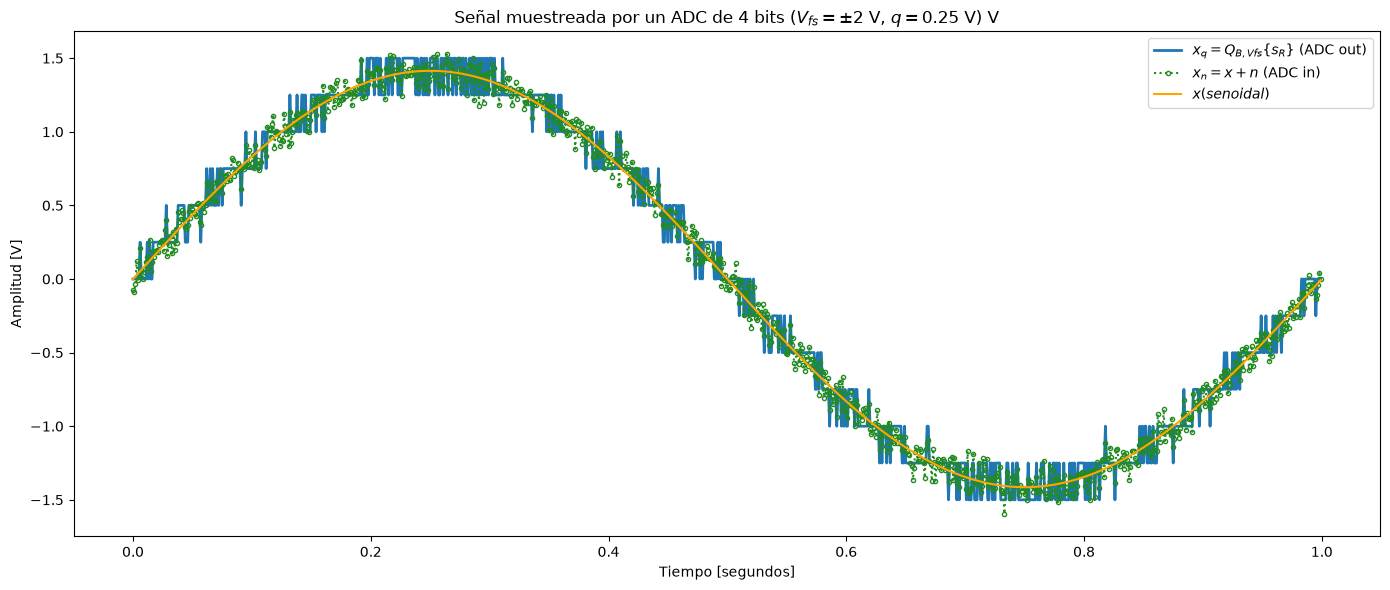

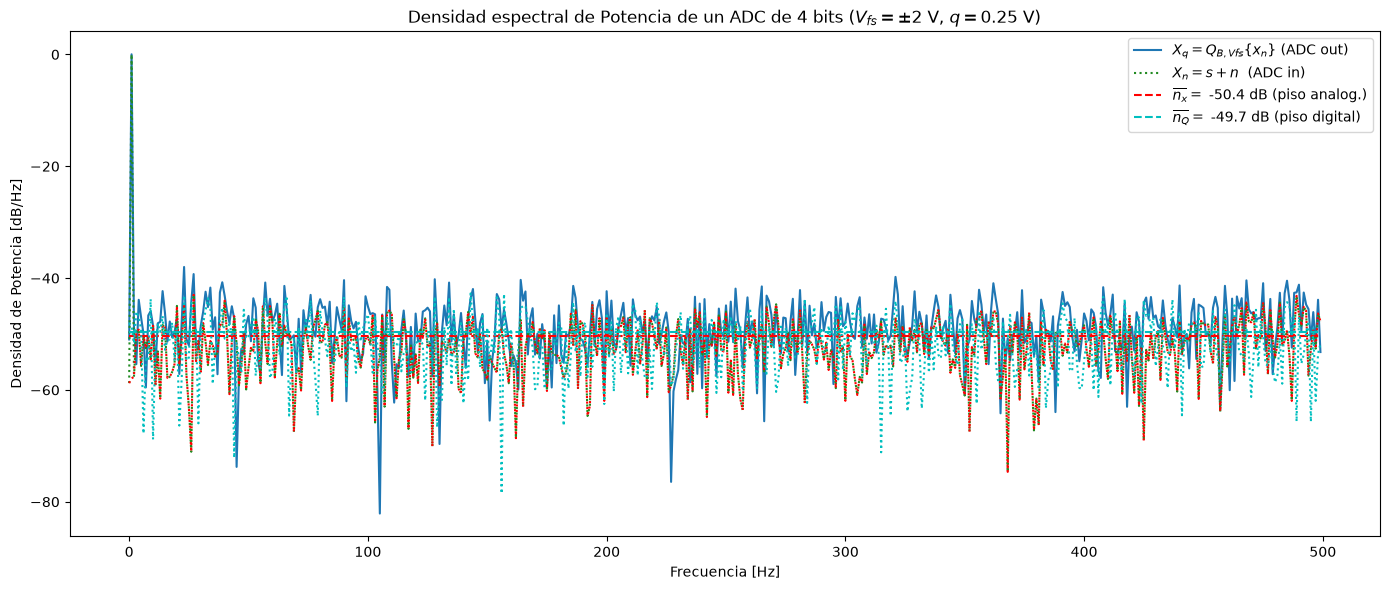

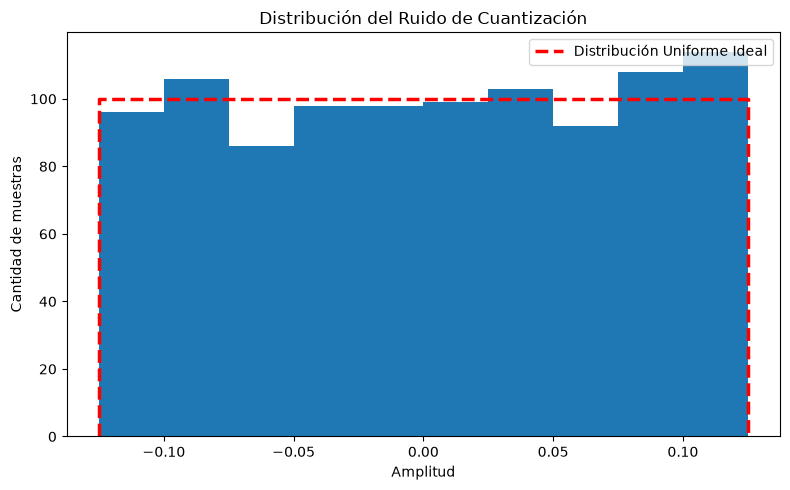

In [28]:
# -*- coding: utf-8 -*-
"""
Created on Sun Sep  6 10:22:10 2026

@author: Fede
"""
from IPython.display import display, HTML

display(HTML("""
<style>
/* Centrado para JupyterLab y Jupyter Notebook 7+ */
.jp-RenderedImage {
    display: flex;
    justify-content: center;
}
.jp-OutputArea-child {
    display: flex;
    justify-content: center;
}

/* Centrado para Jupyter Notebook Clásico (por si acaso) */
.output_png {
    display: table-cell;
    text-align: center;
    vertical-align: middle;
}
</style>
"""))
import sys
from pathlib import Path
directorio_padre = str(Path.cwd().parent)
sys.path.insert(0, directorio_padre)
import gen_fun as gen
import numpy as np
import matplotlib.pyplot as plt


#%%   ------------------ Definiciones

N = 1000
fs = 1000
Vfs = 2
f = 1
bits = 4
k = 1

#%%   ------------------- Codigo


q=2*Vfs/(2**bits)
pq=q**2/12
pn = k * pq

df = fs/N

tt,xx = gen.senoidal(pot = 1,fs = fs,nn = N,ff=f)
ttn,nx = gen.ruido_normal(pot = pn,nn = N,fs = fs)

xn = xx + nx
xq= gen.cuant(xn, bits, Vfs)
nq = xq - xn
#%% ------------------- Transformadas

XQ = 1/N * np.fft.fft(xq)  # Amplitud normalizada
PDS_XQ = ((np.abs(XQ)**2) * 2) / df # Densidad espectral de potencia
XQ_db = 10 * np.log10(PDS_XQ)

XN = 1/N * np.fft.fft(xn)  # Amplitud normalizada
PDS_XN = ((np.abs(XN)**2) * 2) / df # Densidad espectral de potencia
XN_db = 10 * np.log10(PDS_XN)

NX = 1/N * np.fft.fft(nx)  # Amplitud normalizada
PDS_NX = ((np.abs(NX)**2) * 2) / df # Densidad espectral de potencia
NX_db = 10 * np.log10(PDS_NX)

pot_nx = sum(PDS_NX[:(N//2)])/(N/2)
pot_nx = 10 * (np.log10(pot_nx))

NQ = 1/N * np.fft.fft(nq)  # Amplitud normalizada
PDS_NQ = ((np.abs(NQ)**2) * 2) / df # Densidad espectral de potencia
NQ_db = 10 * np.log10(PDS_NQ)

pot_nq = sum(PDS_NQ[:(N//2)])/(N/2)
pot_nq = 10 * (np.log10(pot_nq))

XX = 1/N * np.fft.fft(xx)  # Amplitud normalizada
PDS_XX = ((np.abs(XX)**2) * 2) / df # Densidad espectral de potencia
XX_db = 10 * np.log10(PDS_XX)

frec = tt*(fs/N)
frec = frec[:(N//2)]
tt = tt*(f/N)

#%%  Ploteo de amplitud 
# =====================================================================
plt.figure(figsize=(14, 6))
plt.plot(tt, xq, 
         label=r'$x_q = Q_{B,Vfs}\{s_R\}$ (ADC out)', 
         color='tab:blue', 
         linewidth=2)
plt.plot(tt, xn, 
         label=r'$x_n = x + n$ (ADC in)', 
         color='forestgreen', 
         linestyle=':', 
         marker='o', 
         markerfacecolor='none', 
         markersize=3, 
         linewidth=1.5)
plt.plot(tt, xx, 
         label=r'$x (senoidal)$', 
         color='orange', 
         linestyle='-',  
         markerfacecolor='none', 
         markersize=3, 
         linewidth=1.5)
titulo_tiempo = fr'Señal muestreada por un ADC de {bits} bits ($V_{{fs}} = \pm {Vfs}$ V, $q = {q:.2f}$ V) V'
plt.title(titulo_tiempo)
plt.xlabel('Tiempo [segundos]')
plt.ylabel('Amplitud [V]')
plt.legend(loc='upper right')
plt.tight_layout()

#%%   Ploteo de densidad de espectro
# =====================================================================

plt.figure(figsize=(14, 6))
plt.plot(frec, XQ_db[:(N//2)], 
         label=r'$X_q = Q_{B,Vfs}\{x_n\}$ (ADC out)', 
         color='tab:blue', 
         linewidth=1.5)
plt.plot(frec, XN_db[:(N//2)], 
         label=r'$X_n = s + n$  (ADC in)', 
         color='forestgreen', 
         linestyle=':', 
         linewidth=1.5)
plt.hlines(pot_nx, frec.min(), frec.max(), 
           label=fr'$\overline{{n_x}} =$ {pot_nx:.1f} dB (piso analog.)', 
           color='red', 
           linestyle='--')
plt.plot(frec, NX_db[:(N//2)], 
         color='red', 
         linestyle=':', 
         linewidth=1.5)
plt.hlines(pot_nq, frec.min(), frec.max(), 
           label=fr'$\overline{{n_Q}} =$ {pot_nq:.1f} dB (piso digital)', 
           color='c', 
           linestyle='--')
plt.plot(frec, NQ_db[:(N//2)], 
         color='c', 
         linestyle=':', 
         linewidth=1.5)
titulo_frec = fr'Densidad espectral de Potencia de un ADC de {bits} bits ($V_{{fs}} = \pm {Vfs}$ V, $q = {q:.2f}$ V)'
plt.title(titulo_frec)
plt.xlabel('Frecuencia [Hz]')
plt.ylabel('Densidad de Potencia [dB/Hz]')
plt.legend(loc='upper right')
plt.tight_layout()
plt.show()

#%%   Ploteo histograma
# =====================================================================

fig, ax = plt.subplots(figsize=(8, 5))        
conteos, bins, _ = plt.hist(nq, bins=10, color='#1f77b4', edgecolor='none')
# Calcular las coordenadas del "cuadrado" ideal
# La altura ideal es el total de muestras dividido por la cantidad de barras
muestras_totales = len(nq)
cantidad_bins = len(bins) - 1
altura_ideal = muestras_totales / cantidad_bins
x_ideal = [bins[0], bins[0], bins[-1], bins[-1]]
y_ideal = [0, altura_ideal, altura_ideal, 0]
plt.plot(x_ideal, y_ideal, color='red', linewidth=2.5, linestyle='--', label='Distribución Uniforme Ideal')
plt.title('Distribución del Ruido de Cuantización')
plt.xlabel('Amplitud')
plt.ylabel('Cantidad de muestras')
plt.legend(loc='upper right')
plt.tight_layout()
plt.hist(nq,10);


### b) Análisis del ADC con parámetros: B = 16 bits, $k$ = 10

En este caso, se simula un ADC operando con una resolución de 16 bits y un factor $k_n = 10$. El aumento en la cantidad de bits representa un nivel de ruido de cuantización ($P_q$) mucho menor. Sin embargo, recordando la expresión mediante la cual definimos el ruido analógico:

$$P_n = k_n \cdot P_q$$

podemos observar que el nivel de ruido analógico inyectado será diez veces mayor que el propio ruido de cuantización (ruido digital).

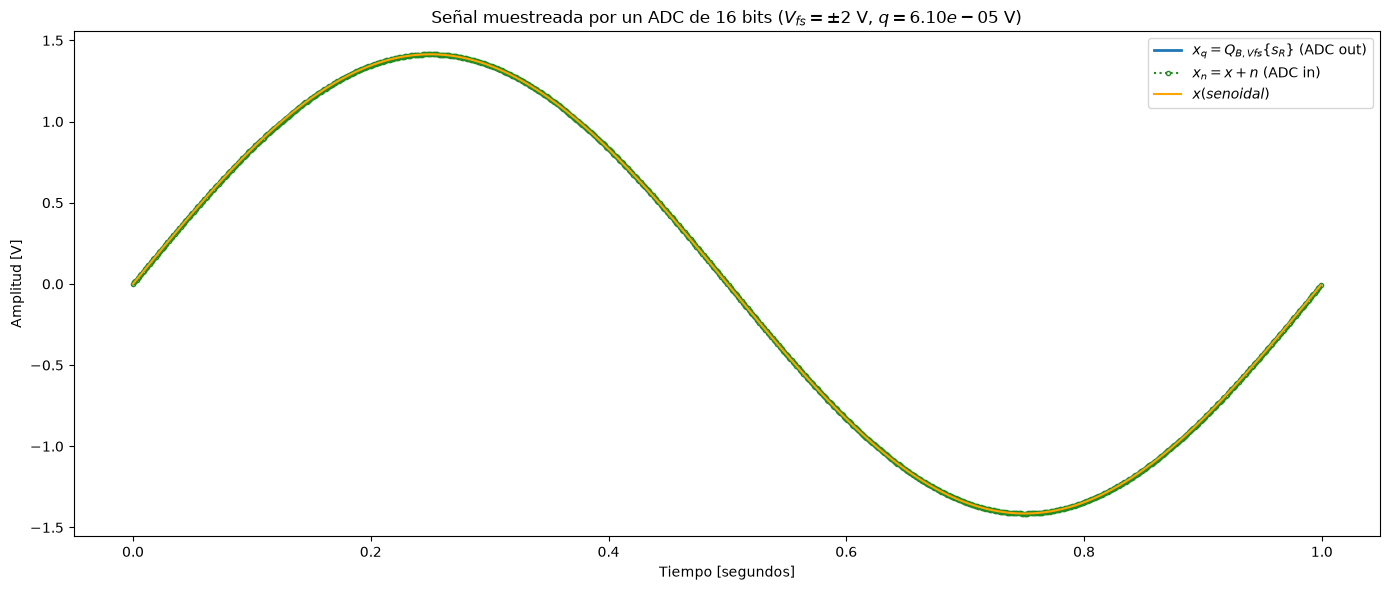

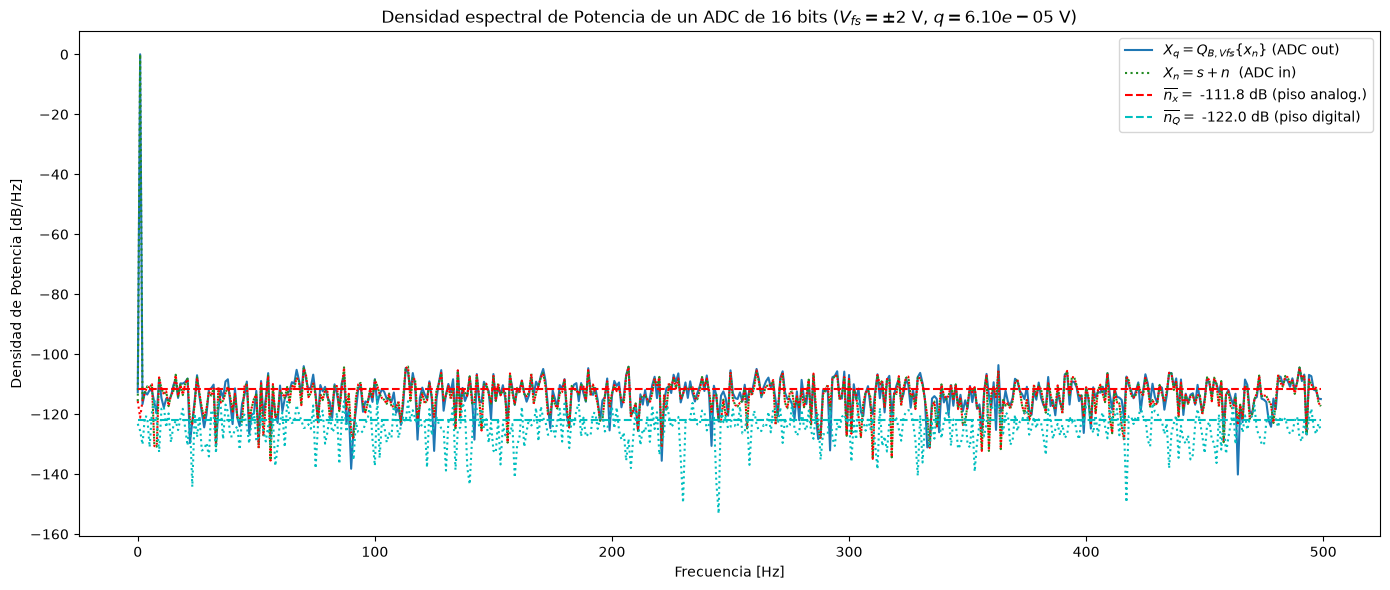

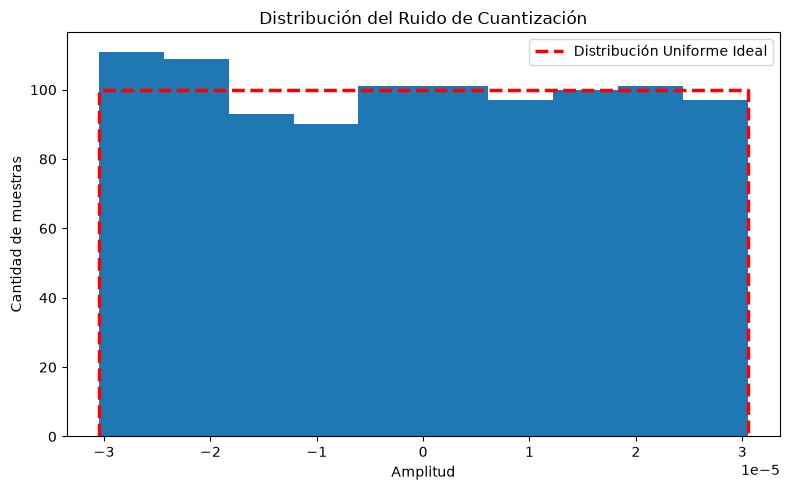

In [30]:
# -*- coding: utf-8 -*-
"""
Created on Sun Sep  6 10:22:10 2026

@author: Fede
"""
from IPython.display import display, HTML

display(HTML("""
<style>
/* Centrado para JupyterLab y Jupyter Notebook 7+ */
.jp-RenderedImage {
    display: flex;
    justify-content: center;
}
.jp-OutputArea-child {
    display: flex;
    justify-content: center;
}

/* Centrado para Jupyter Notebook Clásico (por si acaso) */
.output_png {
    display: table-cell;
    text-align: center;
    vertical-align: middle;
}
</style>
"""))
import sys
from pathlib import Path
directorio_padre = str(Path.cwd().parent)
sys.path.insert(0, directorio_padre)
import gen_fun as gen
import numpy as np
import matplotlib.pyplot as plt


#%%   ------------------ Definiciones

N = 1000
fs = 1000
Vfs = 2
f = 1
bits = 16
k = 10

#%%   ------------------- Codigo


q=2*Vfs/(2**bits)
pq=q**2/12
pn = k * pq

df = fs/N

tt,xx = gen.senoidal(pot = 1,fs = fs,nn = N,ff=f)
ttn,nx = gen.ruido_normal(pot = pn,nn = N,fs = fs)

xn = xx + nx
xq= gen.cuant(xn, bits, Vfs)
nq = xq - xn
#%% ------------------- Transformadas

XQ = 1/N * np.fft.fft(xq)  # Amplitud normalizada
PDS_XQ = ((np.abs(XQ)**2) * 2) / df # Densidad espectral de potencia
XQ_db = 10 * np.log10(PDS_XQ)

XN = 1/N * np.fft.fft(xn)  # Amplitud normalizada
PDS_XN = ((np.abs(XN)**2) * 2) / df # Densidad espectral de potencia
XN_db = 10 * np.log10(PDS_XN)

NX = 1/N * np.fft.fft(nx)  # Amplitud normalizada
PDS_NX = ((np.abs(NX)**2) * 2) / df # Densidad espectral de potencia
NX_db = 10 * np.log10(PDS_NX)

pot_nx = sum(PDS_NX[:(N//2)])/(N/2)
pot_nx = 10 * (np.log10(pot_nx))

NQ = 1/N * np.fft.fft(nq)  # Amplitud normalizada
PDS_NQ = ((np.abs(NQ)**2) * 2) / df # Densidad espectral de potencia
NQ_db = 10 * np.log10(PDS_NQ)

pot_nq = sum(PDS_NQ[:(N//2)])/(N/2)
pot_nq = 10 * (np.log10(pot_nq))

XX = 1/N * np.fft.fft(xx)  # Amplitud normalizada
PDS_XX = ((np.abs(XX)**2) * 2) / df # Densidad espectral de potencia
XX_db = 10 * np.log10(PDS_XX)

frec = tt*(fs/N)
frec = frec[:(N//2)]
tt = tt*(f/N)
#%%  Ploteo de amplitud 
# =====================================================================
plt.figure(figsize=(14, 6))
plt.plot(tt, xq, 
         label=r'$x_q = Q_{B,Vfs}\{s_R\}$ (ADC out)', 
         color='tab:blue', 
         linewidth=2)
plt.plot(tt, xn, 
         label=r'$x_n = x + n$ (ADC in)', 
         color='forestgreen', 
         linestyle=':', 
         marker='o', 
         markerfacecolor='none', 
         markersize=3, 
         linewidth=1.5)

plt.plot(tt, xx, 
         label=r'$x (senoidal)$', 
         color='orange', 
         linestyle='-',  
         markerfacecolor='none', 
         markersize=3, 
         linewidth=1.5)
titulo = fr'Señal muestreada por un ADC de {bits} bits ($V_{{fs}} = \pm {Vfs}$ V, $q = {q:.2e}$ V)'
plt.title(titulo)
plt.xlabel('Tiempo [segundos]')
plt.ylabel('Amplitud [V]')
plt.legend(loc='upper right')
plt.tight_layout()


#%%   Ploteo de densidad de espectro
# =====================================================================

plt.figure(figsize=(14, 6))
plt.plot(frec, XQ_db[:(N//2)], 
         label=r'$X_q = Q_{B,Vfs}\{x_n\}$ (ADC out)', 
         color='tab:blue', 
         linewidth=1.5)
plt.plot(frec, XN_db[:(N//2)], 
         label=r'$X_n = s + n$  (ADC in)', 
         color='forestgreen', 
         linestyle=':', 
         linewidth=1.5)
plt.hlines(pot_nx, frec.min(), frec.max(), 
           label=fr'$\overline{{n_x}} =$ {pot_nx:.1f} dB (piso analog.)', 
           color='red', 
           linestyle='--')
plt.plot(frec, NX_db[:(N//2)], 
         color='red', 
         linestyle=':', 
         linewidth=1.5)
plt.hlines(pot_nq, frec.min(), frec.max(), 
           label=fr'$\overline{{n_Q}} =$ {pot_nq:.1f} dB (piso digital)', 
           color='c', 
           linestyle='--')

plt.plot(frec, NQ_db[:(N//2)], 
         color='c', 
         linestyle=':', 
         linewidth=1.5)
titulo_frec = fr'Densidad espectral de Potencia de un ADC de {bits} bits ($V_{{fs}} = \pm {Vfs}$ V, $q = {q:.2e}$ V)'
plt.title(titulo_frec)
plt.xlabel('Frecuencia [Hz]')
plt.ylabel('Densidad de Potencia [dB/Hz]')
plt.legend(loc='upper right')
plt.tight_layout()
plt.show()

#%%   Ploteo histograma
# =====================================================================

fig, ax = plt.subplots(figsize=(8, 5))        
conteos, bins, _ = plt.hist(nq, bins=10, color='#1f77b4', edgecolor='none')
# Calcular las coordenadas del "cuadrado" ideal
# La altura ideal es el total de muestras dividido por la cantidad de barras
muestras_totales = len(nq)
cantidad_bins = len(bins) - 1
altura_ideal = muestras_totales / cantidad_bins
x_ideal = [bins[0], bins[0], bins[-1], bins[-1]]
y_ideal = [0, altura_ideal, altura_ideal, 0]
plt.plot(x_ideal, y_ideal, color='red', linewidth=2.5, linestyle='--', label='Distribución Uniforme Ideal')
plt.title('Distribución del Ruido de Cuantización')
plt.xlabel('Amplitud')
plt.ylabel('Cantidad de muestras')
plt.legend(loc='upper right')

plt.tight_layout()

plt.hist(nq,10);

### Conclusión
Podemos observar cómo el piso de ruido digital disminuye de manera significativa respecto al punto a. Esto se debe a la mayor resolución del paso de cuantización (0,25 V para el punto a y 0,061 mV para el punto b). Además, como generamos el ruido analógico relacionado k veces con el digital, podemos observar que también disminuyó. Como podemos verificar en el gráfico de Densidad Espectral de Potencia, el nivel del piso de ruido analógico se encuentra 10 dB por encima del digital; esto se corresponde con el factor k elegido. Podemos concluir que, para esta última configuración, el circuito digital está sobredimensionado y el ruido analógico tendrá mucha más relevancia.

### Bonus

#### Relación entre SNR y Número de Bits ($N_B$)

Para un convertidor de $N_B$ bits con un voltaje full scale de $V_{FS}$, el tamaño del paso de cuantización ($q$ o $\Delta V$) está dado por la relación:

$$ q = \frac{V_{FS}}{2^N_B} $$

Sabiendo que la potencia del ruido de cuantización (su varianza $\sigma_e^2$) se define como $\frac{q^2}{12}$, podemos sustituir la ecuación anterior para obtener la varianza en función de los bits y el voltaje:

$$ \sigma_e^2 = \frac{q^2}{12} = \frac{V_{FS}^2}{12 \cdot 2^{2N_B}} $$

La Relación Señal a Ruido (SNR) en decibelios se define como la proporción logarítmica entre la potencia de la señal ($\sigma_x^2$) y la potencia del ruido de cuantización ($\sigma_e^2$). Sustituyendo nuestra varianza del ruido, obtenemos:

$$ \text{SNR} = 10 \log_{10} \left( \frac{\sigma_x^2}{\sigma_e^2} \right) = 10 \log_{10} \left( \frac{12 \cdot 2^{2N_B} \sigma_x^2}{V_{FS}^2} \right) $$

Desarrollando los logaritmos de esta expresión, llegamos a la ecuación principal:

$$ \text{SNR (dB)} = 6.02N_B + 10.79 + 20 \log_{10} \left( \frac{V_{RMS}}{V_{FS}} \right) $$


De esto podemos decir que el SNR depende de tres cantidades: la resolución del convertidor ($N_B$), el nivel RMS de la señal (su desviación estándar, $\sigma_x$) y el rango máximo del convertidor ($V_{FS}$).
El término $6.02N_B$ demuestra que cada bit adicional de resolución incrementa la SNR en aproximadamente 6 dB.

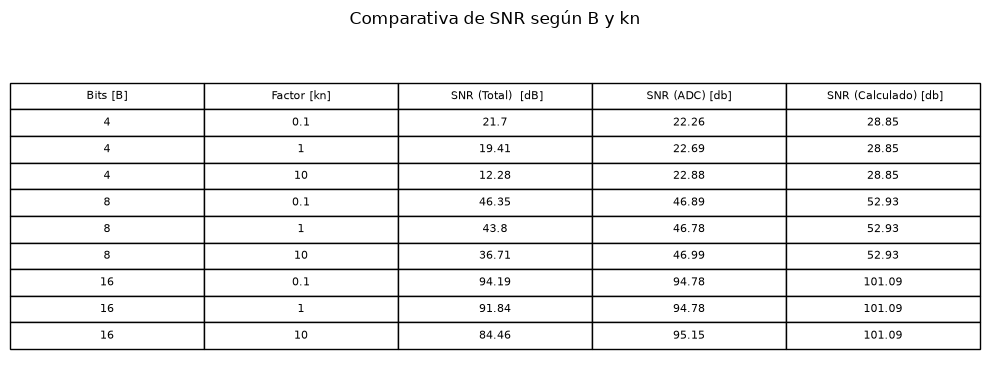

In [19]:
# -*- coding: utf-8 -*-
"""
Created on Sun Sep  6 10:22:10 2026

@author: Fede
"""
from IPython.display import display, HTML

display(HTML("""
<style>
/* Centrado para JupyterLab y Jupyter Notebook 7+ */
.jp-RenderedImage {
    display: flex;
    justify-content: center;
}
.jp-OutputArea-child {
    display: flex;
    justify-content: center;
}

/* Centrado para Jupyter Notebook Clásico (por si acaso) */
.output_png {
    display: table-cell;
    text-align: center;
    vertical-align: middle;
}
</style>
"""))
import sys
from pathlib import Path
directorio_padre = str(Path.cwd().parent)
sys.path.insert(0, directorio_padre)
import gen_fun as gen
import numpy as np
import matplotlib.pyplot as plt

# -------------Definiciones 

N = 1000
fs = 1000
Vfs = 2
f = 1
B_val = [4, 8, 16]
kn_val = [1/10, 1, 10]
pot = 1

datos_tabla = []

# ----------- Calculos

for bits in B_val:
    for k in kn_val:
        
        q = 2 * Vfs / (2**bits)
        pq = (q**2) / 12
        pn = k * pq

        tt, xx = gen.senoidal(pot=pot, fs=fs, nn=N, ff=f) #  Genero las señales
        ttn, nx = gen.ruido_normal(pot=pn, nn=N, fs=fs)
        xn = xx + nx
        
        xq = gen.cuant(xn, bits, Vfs)   # Cuantizado de la señal
        
        nt = xq - xx    # Resto la señal pura original (ruido total)
        nq = xq - xn    # Ruido de cuantizacion
        
#-------- Transformadas
        
        XX = 1/N * np.fft.fft(xx)
        p_XX = ((np.abs(XX)**2) * 2) 

        XN = 1/N * np.fft.fft(xn)
        p_XN = ((np.abs(XN)**2) * 2) 

        NT = 1/N * np.fft.fft(nt)
        p_NT = ((np.abs(NT)**2) * 2) 

        NQ = 1/N * np.fft.fft(nq)
        p_NQ = ((np.abs(NQ)**2) * 2) 

        pot_nt = sum(p_NT[:(N//2)])
        pot_xx = sum(p_XX[:(N//2)])
        pot_xn = sum(p_XN[:(N//2)])
        pot_nq = sum(p_NQ[:(N//2)])
        
        
        snr_tot = 10 * np.log10(pot_xx / pot_nt)
        snr_adc = 10 * np.log10(pot_xn / pot_nq)

        Vrms = np.sqrt(pot)
        calc = 6.02 * bits + 10.79 + 20 * np.log10(Vrms/Vfs)
        
        datos_tabla.append([bits, k, round(snr_tot, 2), round(snr_adc, 2),round(calc, 2)])   # Guardo en tabla


# ---------Tabla

columnas = ['Bits [B]', 'Factor [kn]', ' SNR (Total)  [dB]','SNR (ADC) [db]', ' SNR (Calculado) [db]']

fig, ax = plt.subplots(figsize=(10, 4))
ax.axis('tight')
ax.axis('off') 
tabla = ax.table(cellText=datos_tabla, colLabels=columnas, cellLoc='center', loc='center')
tabla.scale(1, 1.5) 
plt.title('Comparativa de SNR según B y kn', pad=20)
plt.tight_layout()
plt.show()

### Conclusion
Como se observa en la tabla, la SNR total (que contempla tanto el ruido analógico como el de cuantización) se ve fuertemente afectada por el factor k al incrementarse el nivel de ruido analógico en la entrada. Por el contrario, la SNR exclusiva del ADC depende únicamente de la resolución en bits, ya que el nivel de la señal (Vrms) y el rango del conversor (Vfs) se mantienen constantes. Finalmente, se comprueba que los resultados del ADC se aproximan al cálculo teórico.